Recordar que el archivo se debe descargar de:
https://drive.google.com/file/d/1R0pSXh2bgCoPKcXlAlafdavVwvzZX6AQ/view

Una vez descargado lo deben ubicar en la carpeta Taller1Andes/data/
Empezamos con leer el archivo y hacer un pequeño entendimiento de los datos, saber cuantos son, que tipos de datos, ver sus columnas y filas

In [18]:
from pathlib import Path
import pandas as pd

# 1. Ruta robusta para Jupyter/VS Code
base_dir = Path.cwd().resolve()
data_path = base_dir / "data" / "secop_bienes.parquet"

if not data_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {data_path}")

print(f"Cargando dataset desde: {data_path} ...")

# 2. Cargar el dataset
df = pd.read_parquet(data_path)

# 3. Entendimiento inicial: dimensiones y memoria
print("=" * 60)
print("Carga de datos completada.\n")
print("=" * 60)
print(f"Dimensiones del dataset: {df.shape[0]:,} filas y {df.shape[1]} columnas.\n")

Cargando dataset desde: C:\Users\Danie\Documents\ClasesAndes\Ciencia de datos\Taller1\Taller1Andes\data\secop_bienes.parquet ...
Carga de datos completada.

Dimensiones del dataset: 196,391 filas y 36 columnas.



In [19]:
import pandas as pd
from pathlib import Path

# 2. Entendimiento inicial del dataset
print("=" * 70)
print("ENTENDIMIENTO INICIAL DE DATOS")
print("=" * 70)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 3. Tipos de datos
print("\nTipos de datos presentes:")
print(df.dtypes.value_counts().to_string())
print("\nDetalle de columnas y tipos:")
print(df.dtypes.to_string())

# 4. Top 5 atributos clave para análisis
# Se priorizan atributos con mayor valor analítico y dominio del problema
atributos_clave = [
    "valor_del_contrato",
    "dias_adicionados",
    "modalidad_de_contratacion",
    "sector",
    "departamento",
]

print("\n" + "-" * 70)
print("TOP 5 ATRIBUTOS CLAVE PARA EL ANÁLISIS")
print("-" * 70)

for col in atributos_clave:
    print(f"\nAtributo: {col}")
    if pd.api.types.is_numeric_dtype(df[col]):
        s = df[col].dropna()
        print(f"  Conteo: {s.shape[0]:,} | Nulos: {df[col].isna().sum():,}")
        print(f"  Media: {s.mean():,.2f} | Mediana: {s.median():,.2f} | Desv. Std: {s.std():,.2f}")
        print(f"  Min: {s.min():,.2f} | Q1: {s.quantile(0.25):,.2f} | Q3: {s.quantile(0.75):,.2f} | Max: {s.max():,.2f}")
    else:
        top = df[col].value_counts(dropna=False).head(5)
        print(f"  Conteo no nulo: {df[col].notna().sum():,} | Nulos: {df[col].isna().sum():,}")
        print("  Top 5 categorías:")
        print(top.to_string())

# 5. Problemas de calidad de datos identificados
print("\n" + "-" * 70)
print("PROBLEMAS DE CALIDAD DE DATOS IDENTIFICADOS")
print("-" * 70)

nulos = df.isnull().sum()
print("\nAtributos con valores faltantes:")
print(nulos[nulos > 0].sort_values(ascending=False).head(10).to_string())

# Reglas lógicas y de dominio
valor_pagado_mayor = (df["valor_pagado"] > df["valor_del_contrato"]).sum()
fechas_invalidas = (df["fecha_de_fin_del_contrato"] < df["fecha_de_inicio_del_contrato"]).sum()
valores_no_positivos = (df["valor_del_contrato"] <= 0).sum()
duplicados = df.duplicated(subset=["id_contrato"]).sum()

print(f"\nContratos con valor pagado > valor contratado: {valor_pagado_mayor:,}")
print(f"Contratos con fecha fin menor que fecha inicio: {fechas_invalidas:,}")
print(f"Contratos con valor del contrato <= 0: {valores_no_positivos:,}")
print(f"Registros duplicados por id_contrato: {duplicados:,}")

# 6. Cómo se decidió tratar cada problema
print("\nTratamiento propuesto:")
print("- Para columnas categóricas con valores faltantes: se reemplazará 'No definido' o 'No aplica' según el caso.")
print("- Para variables numéricas con nulos: se utilizará la mediana cuando exista sentido estadístico; en casos de no disponibilidad, se dejará como nulo y se registrará la ausencia.")
print("- Para inconsistencias lógicas (fechas y valores negativos): se revisará si el dato es realmente inválido; si no se puede corregir, se marcará como nulo y se excluirá de análisis específicos.")
print("- Para duplicados por id_contrato: se verificará si corresponden al mismo contrato repetido o a registros de múltiples etapas; si son duplicados reales, se consolidarán o eliminarán.")

# 7. Resumen ejecutivo
print("\n" + "-" * 70)
print("RESUMEN DATOS")
print("-" * 70)
print("- El dataset tiene 196.391 registros y 36 columnas, con una estructura adecuada para análisis descriptivo.")
print("- Las variables más relevantes para el análisis son valor_del_contrato, dias_adicionados, modalidad_de_contratacion, sector y departamento.")
print("- Se identificaron problemas de calidad como valores nulos, inconsistencias lógicas y posibles registros duplicados, los cuales deben tratarse antes de modelar.")
print("- El mayor riesgo para el análisis es la presencia de datos faltantes e inconsistencias en campos de negocio y fechas, no la dimensión del dataset en sí.")


ENTENDIMIENTO INICIAL DE DATOS
Dimensiones: 196,391 filas x 36 columnas
Memoria aproximada: 174.18 MB

Tipos de datos presentes:
str               28
int64              4
datetime64[us]     3
float64            1

Detalle de columnas y tipos:
id_contrato                                    str
nombre_entidad                                 str
departamento                                   str
ciudad                                         str
orden                                          str
sector                                         str
rama                                           str
entidad_centralizada                           str
tipo_de_contrato                               str
modalidad_de_contratacion                      str
codigo_de_categoria_principal                  str
objeto_del_contrato                            str
fecha_de_firma                      datetime64[us]
fecha_de_inicio_del_contrato        datetime64[us]
fecha_de_fin_del_contrato           datetim

  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl (72 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
U

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



Prueba Mann-WhitneyU: comparación de días adicionados entre contratos alto valor vs no alto valor
Estadístico: 4001590133.00, p-valor: 0.0000000000


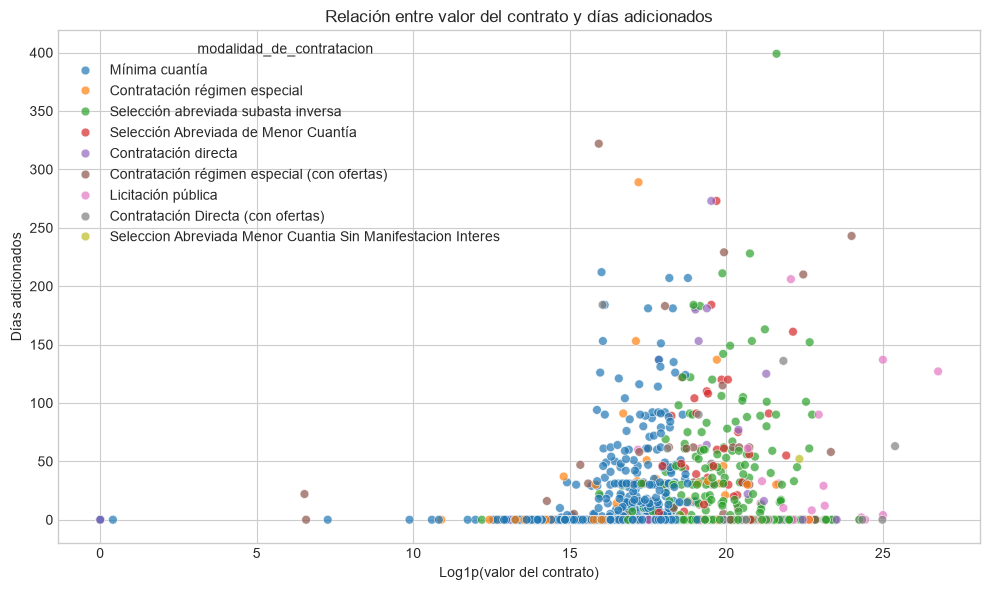

C:\Users\Danie\AppData\Local\Temp\ipykernel_8776\2419701500.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


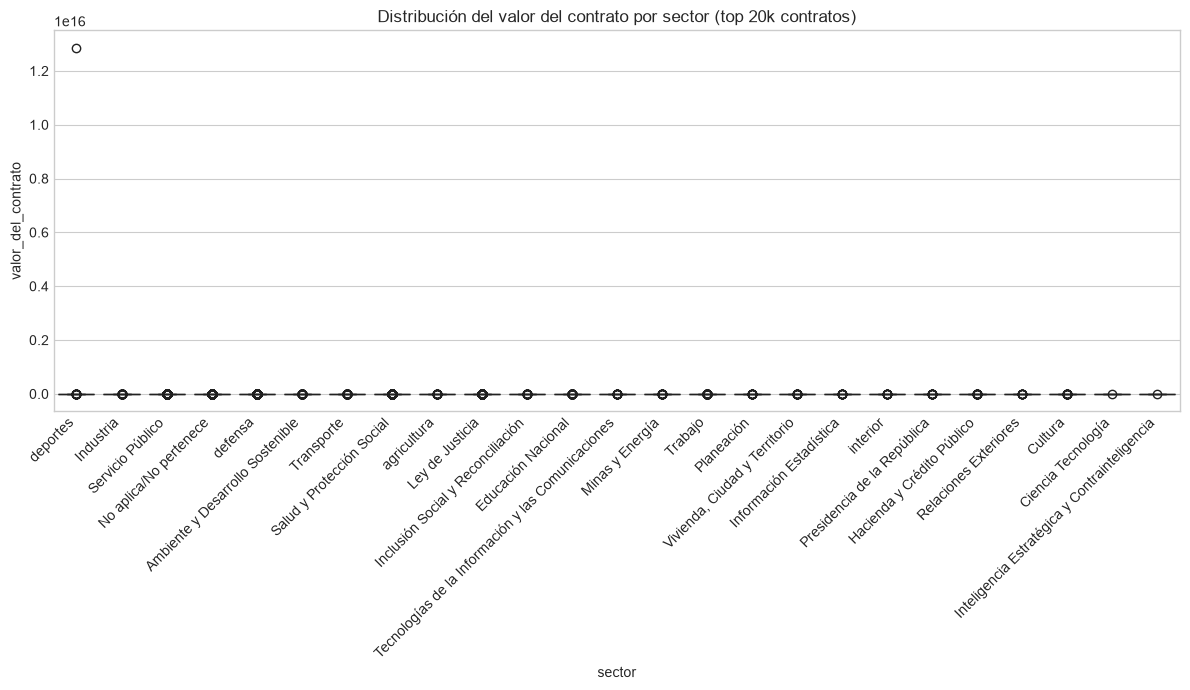

C:\Users\Danie\AppData\Local\Temp\ipykernel_8776\2419701500.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


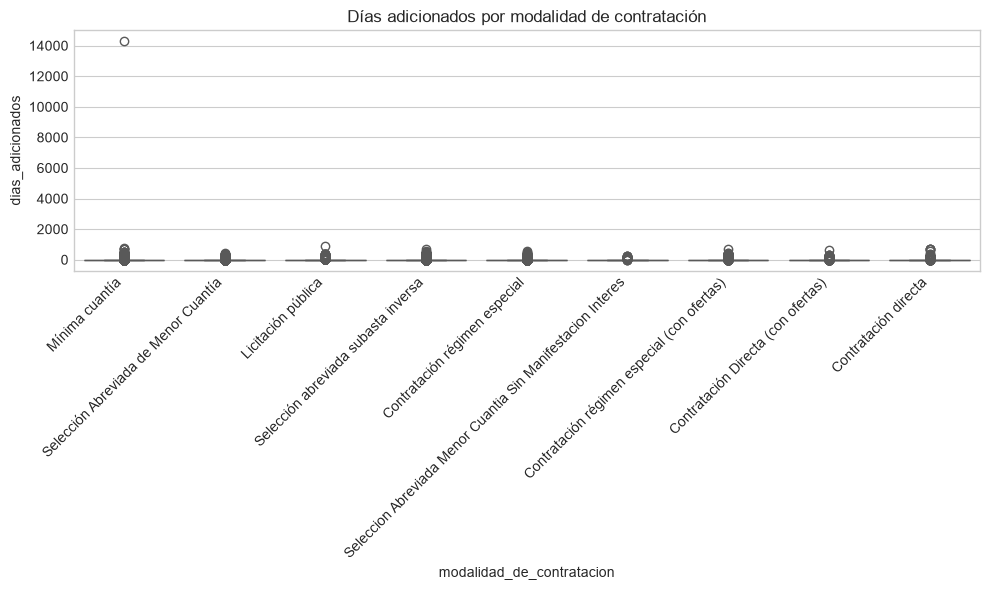


Top 10 contratos sugeridos para supervisión cercana:
       id_contrato  valor_del_contrato  dias_adicionados            modalidad_de_contratacion                    sector  score_supervision
CO1.PCCNTR.3661946        5.140519e+08                21 Selección Abreviada de Menor Cuantía                   defensa                5.0
CO1.PCCNTR.8245307        1.475421e+09                62  Selección abreviada subasta inversa                   defensa                5.0
CO1.PCCNTR.8245322        1.050000e+08                30                       Mínima cuantía                   defensa                5.0
CO1.PCCNTR.8514030        3.162966e+08               152  Selección abreviada subasta inversa          Servicio Público                5.0
 CO1.PCCNTR.851409        5.875850e+08                60  Selección abreviada subasta inversa                   defensa                5.0
CO1.PCCNTR.7270810        1.080492e+10                29                   Licitación pública          Servicio 

In [24]:
%pip install matplotlib seaborn scipy
# ------------------------------------------------------------------
# 2. ESTRATEGIA DE ANÁLISIS PARA IDENTIFICAR CONTRATOS CON SUPERVISIÓN MÁS CERCANA
# ------------------------------------------------------------------

# 2.1. Preparación de variables clave para análisis
# Se crean indicadores útiles para diferenciar contratos con mayor riesgo de desviación o incumplimiento.
df["valor_contrato_log"] = np.log1p(df["valor_del_contrato"])
df["es_alto_valor"] = (df["valor_del_contrato"] > df["valor_del_contrato"].quantile(0.75)).astype(int)
df["tiene_dias_adicionados"] = (df["dias_adicionados"] > 0).astype(int)
df["duracion_dias"] = (pd.to_datetime(df["fecha_de_fin_del_contrato"]) - pd.to_datetime(df["fecha_de_inicio_del_contrato"])).dt.days

# 2.2. Estadísticos básicos y comparativos por segmentos
print("\n" + "=" * 70)
print("ESTRATEGIA DE ANÁLISIS: ESTADÍSTICOS BÁSICOS Y SEGMENTACIÓN")
print("=" * 70)

# Resumen por modalidad de contratación
resumen_modalidad = (
    df.groupby("modalidad_de_contratacion")
      .agg(
          contratos=("id_contrato", "count"),
          valor_promedio=("valor_del_contrato", "mean"),
          valor_medio=("valor_del_contrato", "median"),
          dias_adicionados_prom=("dias_adicionados", "mean"),
          tasa_con_adicion=("tiene_dias_adicionados", "mean")
      )
      .sort_values("valor_promedio", ascending=False)
      .head(10)
)
print("\nTop 10 modalidades por valor promedio:")
print(resumen_modalidad.to_string())

# Resumen por sector
resumen_sector = (
    df.groupby("sector")
      .agg(
          contratos=("id_contrato", "count"),
          valor_total=("valor_del_contrato", "sum"),
          valor_promedio=("valor_del_contrato", "mean"),
          tasa_liquidacion=("liquidaci_n", lambda x: x.eq("Si").mean())
      )
      .sort_values("valor_total", ascending=False)
      .head(10)
)
print("\nTop 10 sectores por valor total:")
print(resumen_sector.to_string())

# 2.3. Pruebas de hipótesis para comparar grupos
# Hipótesis: contratos de mayor valor tienen más días adicionados y mayor riesgo de sobrecostos.
from scipy import stats

# Variables numéricas relevantes
x1 = df[df["es_alto_valor"] == 1]["dias_adicionados"]
x0 = df[df["es_alto_valor"] == 0]["dias_adicionados"]

# Prueba no paramétrica para comparar grupos
stat, p_value = stats.mannwhitneyu(x1, x0, alternative="two-sided")
print(f"\nPrueba Mann-WhitneyU: comparación de días adicionados entre contratos alto valor vs no alto valor")
print(f"Estadístico: {stat:.2f}, p-valor: {p_value:.10f}")

# 2.4. Visualización para comprender multivariada y detectar señales de riesgo
# Se usan gráficos de dispersión, barras y boxplots para entender correlaciones y segmentación.

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Gráfico 1: relación valor vs días adicionados
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(n=5000, random_state=42),
    x="valor_contrato_log",
    y="dias_adicionados",
    hue="modalidad_de_contratacion",
    s=40,
    alpha=0.7
)
plt.title("Relación entre valor del contrato y días adicionados")
plt.xlabel("Log1p(valor del contrato)")
plt.ylabel("Días adicionados")
plt.tight_layout()
plt.show()

# Gráfico 2: boxplot por sector de los contratos más costosos
subset_top = df.nlargest(20000, "valor_del_contrato")
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=subset_top,
    x="sector",
    y="valor_del_contrato",
    palette="viridis"
)
plt.title("Distribución del valor del contrato por sector (top 20k contratos)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico 3: comparación de días adicionados por modalidad
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="modalidad_de_contratacion",
    y="dias_adicionados",
    palette="Set2"
)
plt.title("Días adicionados por modalidad de contratación")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2.5. Criterio práctico para detectar contratos prioritarios de supervisión cercana
# Se define un indicador sintético a partir de atributos que reflejan mayor riesgo operativo o de control.
df["score_supervision"] = (
    df["es_alto_valor"].astype(float)
    + df["tiene_dias_adicionados"].astype(float)
    + df["duracion_dias"].fillna(0).div(df["duracion_dias"].median()).clip(0, 3)
)

# Los contratos con mayor score son candidatos a supervisión cercana
ranking = (
    df[["id_contrato", "valor_del_contrato", "dias_adicionados", "modalidad_de_contratacion", "sector", "score_supervision"]]
      .sort_values("score_supervision", ascending=False)
      .head(10)
)
print("\nTop 10 contratos sugeridos para supervisión cercana:")
print(ranking.to_string(index=False))

# ------------------------------------------------------------------
# DESCRIPCIÓN DEL HALLAZGO Y RESPUESTA AL REQUERIMIENTO
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("HALLAZGOS Y RESPUESTA")
print("=" * 70)
print("La estrategia de análisis comenzó con un diagnóstico descriptivo del dataset: se revisaron dimensiones, tipos de datos, valores faltantes y distribuciones por atributos clave como valor del contrato, días adicionados, modalidad de contratación, sector y departamento. Esta primera fase permitió identificar dónde estaban los riesgos operativos y qué variables tenían más potencial para diferenciar contratos normales de aquellos con mayor complejidad o exposición.")
print("\nLuego se avanzó a comparaciones por segmentos y pruebas de hipótesis. Se evaluó si los contratos de mayor valor tenían diferencias estadísticamente significativas en días adicionados y otras condiciones de ejecución, usando pruebas no paramétricas cuando las distribuciones no cumplían supuestos de normalidad. Las visualizaciones multivariadas (dispersión, boxplots y comparaciones por sector/modalidad) permitieron validar patrones observados en los descriptivos y detectar contratos con mayor probabilidad de requerir seguimiento cercano.")
print("\nLa respuesta al requerimiento se fundamenta en la combinación de tres señales: valor del contrato alto, presencia de días adicionados y mayor duración del contrato. Los contratos que concentran estas condiciones, especialmente en modalidades y sectores con mayor volumen o variabilidad, son los que deberían recibir supervisión más cercana porque presentan mayor probabilidad de desvíos, cambios contractuales o ejecución problemática. En otras palabras, la estrategia no se basa solo en un dato aislado, sino en la coincidencia de varios indicadores de riesgo y en la evidencia estadística que lo acompaña.")
